# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 1: Introducción al Credit Scoring en Banca**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

# **0. Initial Settings**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix
import os

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s01")

# **1. Cargando Data**

In [2]:
df = pd.read_csv(os.path.join(data_path, "credit_data.csv"))

In [3]:
df.head()

,clientid,income,age,loan,default
0,1,66155.92510,59.017015,8106.532131,0
1,2,34415.15397,48.117153,6564.745018,0
2,3,57317.17006,63.108049,8020.953296,0
3,4,42709.53420,45.751972,6103.642260,0
4,5,66952.68885,18.584336,8770.099235,1


array([[<Axes: title={'center': 'clientid'}>,
        <Axes: title={'center': 'income'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'loan'}>],
       [<Axes: title={'center': 'default'}>, <Axes: >]], dtype=object)

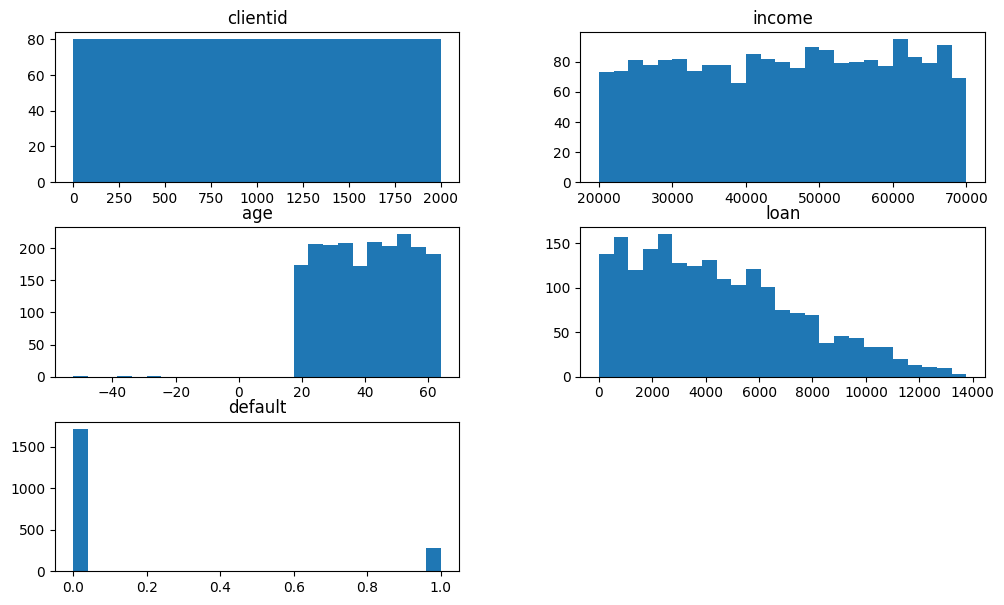

In [4]:
df.hist(bins=25, figsize=(12,7), grid=False)

# **3. Simulación Scoring**

Modelo Logístico:
$$
\ln\left(\frac{p_i}{1-p_i}\right) = PD_{logit} = \beta_0 
         + \beta_1 ingreso
         + \beta_2 age
         + \beta_3 loan = X_i\beta
$$

Para hallar la Probabilidad de Default:
$$
p_i = \frac{1}{1 + e^{-X_i\beta}}
$$

A modo de simplificar el análisis se eliminan las filas con valores nulos en alguna de las columnas.

In [5]:
df.dropna(inplace=True)
X = df[["income", "age", "loan"]]
y = df["default"]

model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## **3.1. Predicciones del Modelo**:
- $y_{hat}$: Es el valor predicho de la variable dependiente (default)
- $probabilities$: Es la probabilidad de que default sea 1 según el modelo Logístico

In [6]:
y_hat = model.predict(X)
probabilities = model.predict_proba(X)[:,1]

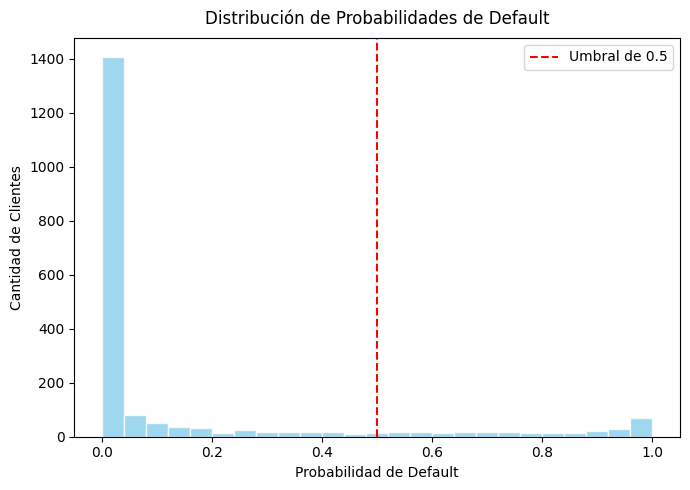

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(probabilities, bins=25, color='skyblue', edgecolor='white', alpha=0.8)
plt.title("Distribución de Probabilidades de Default", pad=10)
plt.xlabel("Probabilidad de Default")
plt.ylabel("Cantidad de Clientes")
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral de 0.5')
plt.legend()
plt.tight_layout()
plt.show()

Text(45.72222222222221, 0.5, 'Realidad')

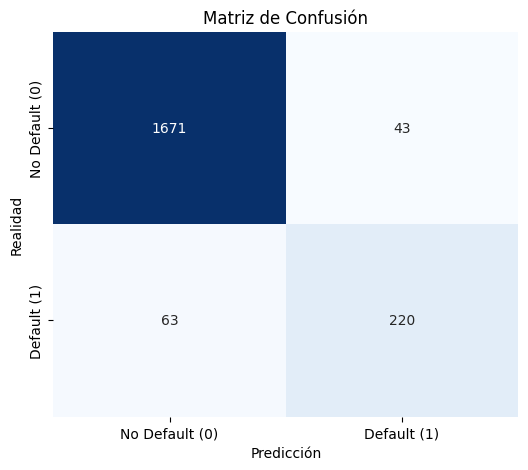

In [8]:
# 2. Matriz de Confusión
cm = confusion_matrix(y, y_hat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')

# **4. Simple Credit Scoring**

In [11]:
df["score_simple"] = (1 - probabilities) * 1000

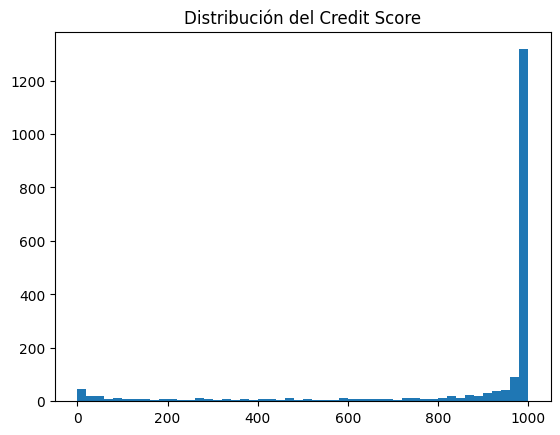

In [ ]:
plt.hist(df["score_simple"], bins=50)
plt.title("Distribución del Credit Score")
plt.show()

Ejemplo: https://learning.oreilly.com/library/view/use-logistic-regression/9798341607903/ch01.html#shortcut14_introducing_logistic_regression_1729248021228049